In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('Food_Delivery_Times.csv')

In [6]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [8]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [9]:
for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

median_value = df['Courier_Experience_yrs'].median()
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(median_value)

df.drop('Order_ID', axis=1, inplace=True)

In [10]:
df.isnull().sum()

,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [11]:
df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68


## Exploratory Data Analysis (EDA)

### 1. Target Variable Analysis: Delivery_Time_min

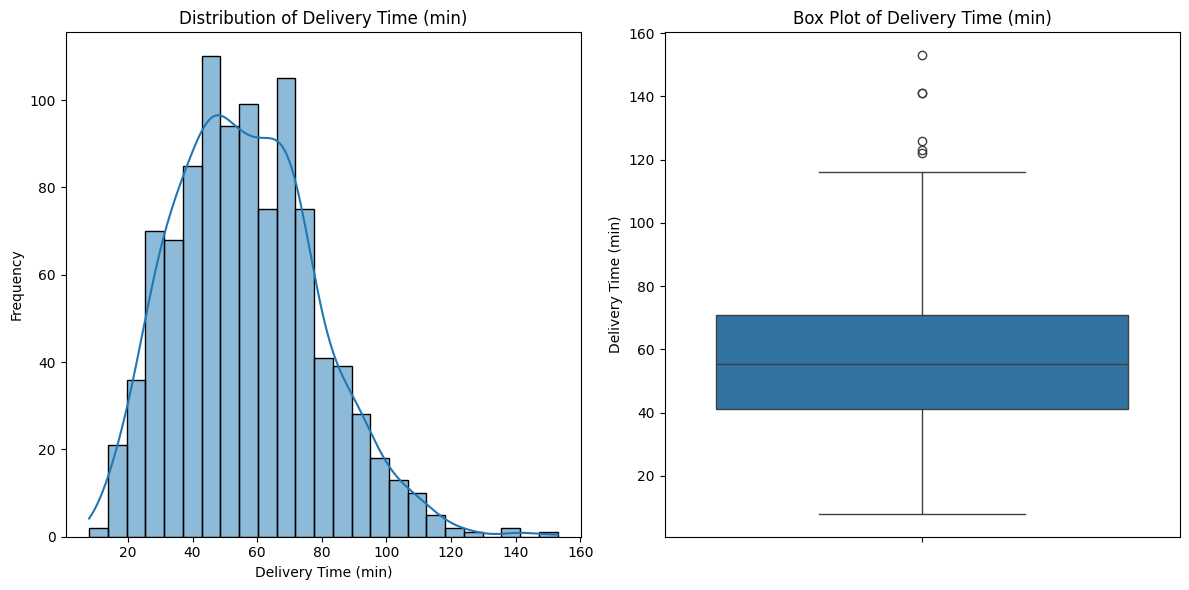

In [12]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Delivery_Time_min'], kde=True)
plt.title('Distribution of Delivery Time (min)')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Delivery_Time_min'])
plt.title('Box Plot of Delivery Time (min)')
plt.ylabel('Delivery Time (min)')

plt.tight_layout()
plt.show()

### 2. Numerical Feature Analysis vs. Delivery_Time_min

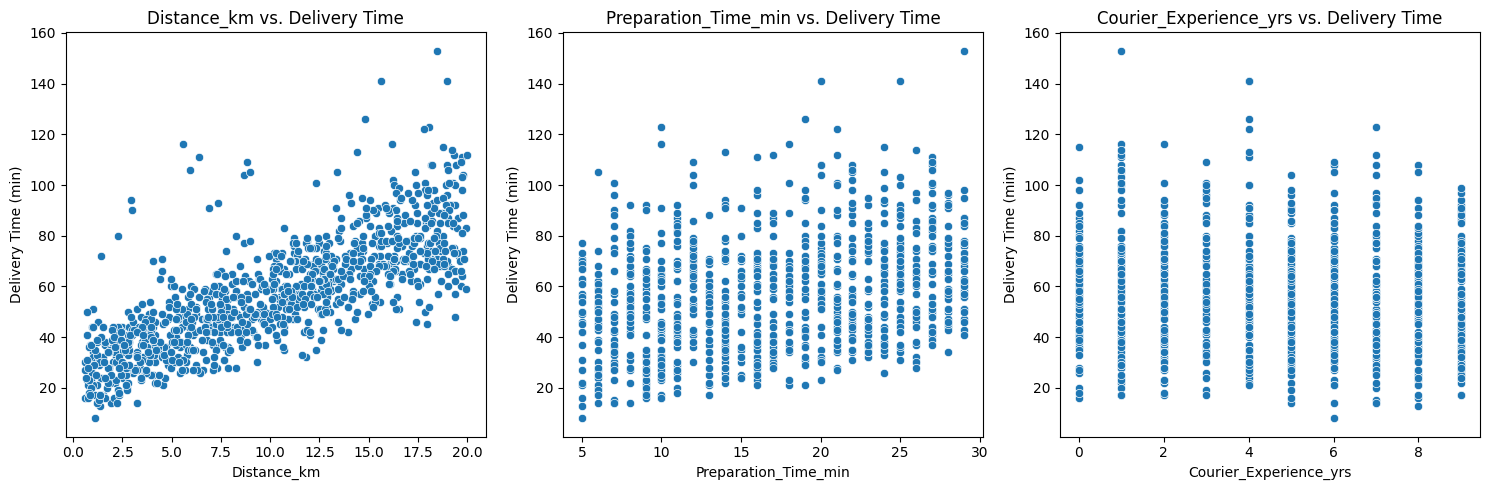

In [13]:
numerical_features = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

plt.figure(figsize=(15, 5))

for i, col in enumerate(numerical_features):
    plt.subplot(1, len(numerical_features), i + 1)
    sns.scatterplot(x=df[col], y=df['Delivery_Time_min'])
    plt.title(f'{col} vs. Delivery Time')
    plt.xlabel(col)
    plt.ylabel('Delivery Time (min)')

plt.tight_layout()
plt.show()

### 3. Categorical Feature Analysis vs. Delivery_Time_min

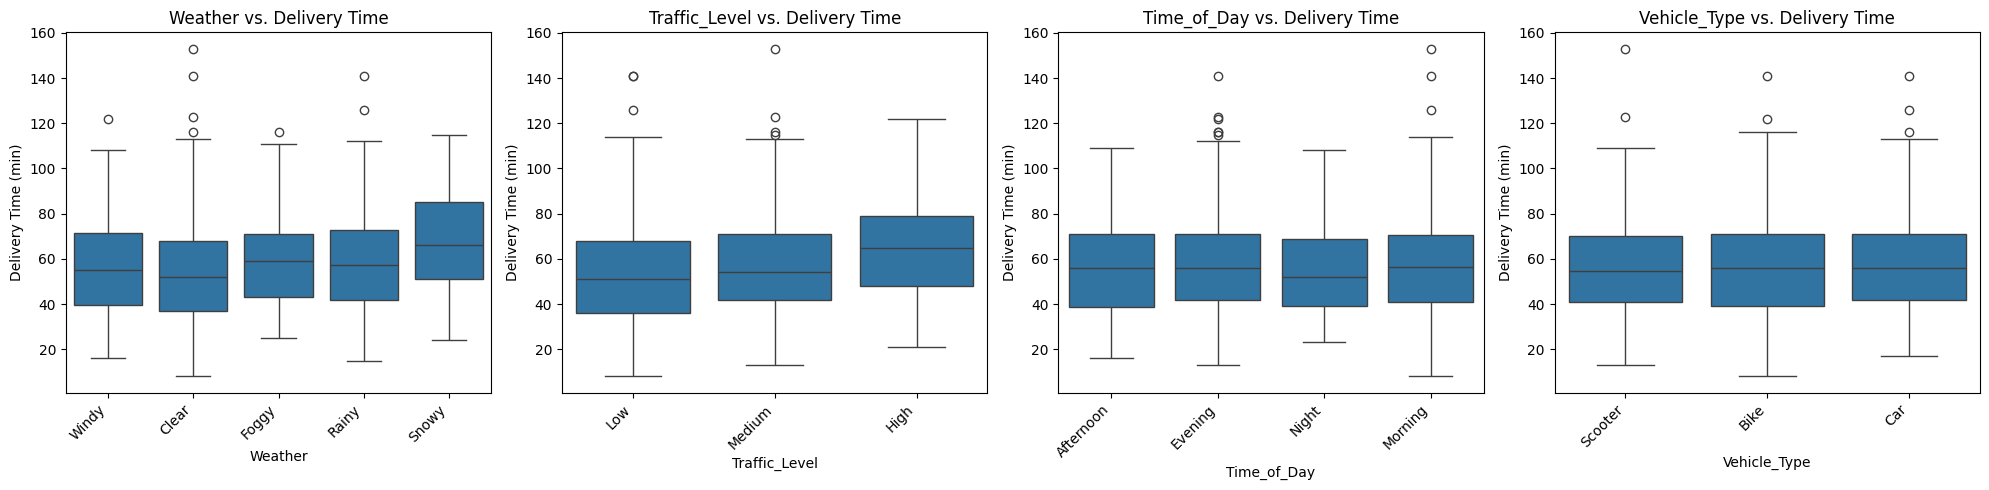

In [14]:
categorical_features = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

plt.figure(figsize=(20, 5))

for i, col in enumerate(categorical_features):
    plt.subplot(1, len(categorical_features), i + 1)
    sns.boxplot(x=df[col], y=df['Delivery_Time_min'])
    plt.title(f'{col} vs. Delivery Time')
    plt.xlabel(col)
    plt.ylabel('Delivery Time (min)')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

plt.tight_layout()
plt.show()

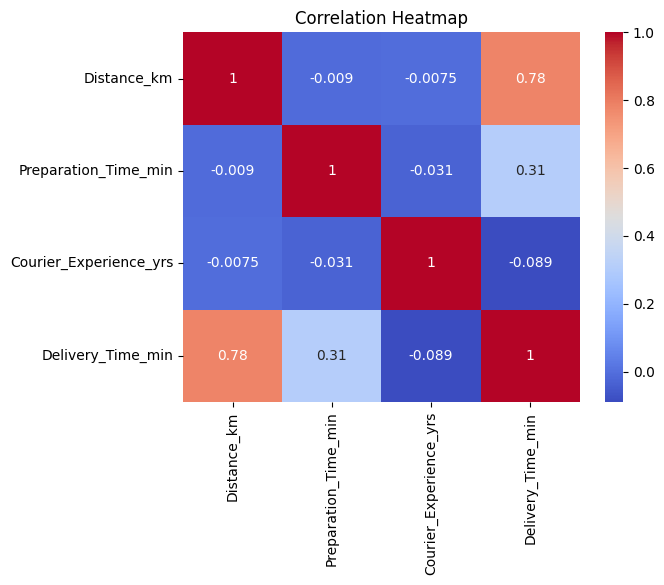

In [15]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Statistical Testing for Categorical Features (ANOVA)

In [16]:
from scipy.stats import f_oneway

categorical_features = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

print("ANOVA Test Results for Categorical Features vs. Delivery_Time_min:\n")

for col in categorical_features:
    # Get unique categories and extract delivery times for each category
    categories = df[col].unique()
    data_per_category = [df['Delivery_Time_min'][df[col] == cat] for cat in categories]

    # Perform ANOVA test
    f_statistic, p_value = f_oneway(*data_per_category)

    print(f"Feature: {col}")
    print(f"  F-statistic: {f_statistic:.3f}")
    print(f"  P-value: {p_value:.3f}")

    if p_value < 0.05:
        print("  Conclusion: Statistically significant differences between group means. This feature is likely important.\n")
    else:
        print("  Conclusion: No statistically significant differences between group means. This feature might be less important.\n")

ANOVA Test Results for Categorical Features vs. Delivery_Time_min:

Feature: Weather
  F-statistic: 10.499
  P-value: 0.000
  Conclusion: Statistically significant differences between group means. This feature is likely important.

Feature: Traffic_Level
  F-statistic: 19.751
  P-value: 0.000
  Conclusion: Statistically significant differences between group means. This feature is likely important.

Feature: Time_of_Day
  F-statistic: 0.347
  P-value: 0.792
  Conclusion: No statistically significant differences between group means. This feature might be less important.

Feature: Vehicle_Type
  F-statistic: 0.589
  P-value: 0.555
  Conclusion: No statistically significant differences between group means. This feature might be less important.



In [17]:
df.columns

Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

### Re-creating Feature and Target Separation & Train-Test Split (after previous cells were deleted)

### Label Encoding for Categorical Features

In [18]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('Delivery_Time_min', axis=1)
y = df['Delivery_Time_min']

# Perform train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of X_train: (800, 7)
Shape of X_test: (200, 7)


The above cell performs the train-test split, defining `X_train` and `X_test`. This resolves the `NameError` in the subsequent label encoding cell. The original train-test split cell (`kO1zgiKx1x9O`) is now redundant in its current position.

In [19]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include='object').columns

# Apply Label Encoding to training and test sets
for col in categorical_cols:
    le = LabelEncoder()
    # Fit on training data and transform both train and test
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

print("X_train after Label Encoding:")
display(X_train.head())
print("\nX_test after Label Encoding:")
display(X_test.head())

X_train after Label Encoding:


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
29,18.05,0,2,1,2,10,7.0
535,2.14,0,0,1,0,18,3.0
695,3.23,0,0,0,0,17,9.0
557,7.51,2,1,1,1,27,6.0
836,4.62,2,2,0,1,8,3.0



X_test after Label Encoding:


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
521,5.30,0,1,1,0,16,5.0
737,10.46,0,2,1,0,25,3.0
740,4.04,2,0,1,0,14,6.0
660,3.33,0,2,1,2,24,2.0
411,17.44,0,1,3,1,23,0.0


### Training a Decision Tree Regressor

### Hyperparameter Tuning with RandomizedSearchCV

`RandomizedSearchCV` is an efficient alternative to `GridSearchCV` when the search space is large. Instead of exhaustively trying every combination, it samples a fixed number of parameter settings from specified distributions. This can significantly reduce computation time while still finding good hyperparameter combinations.

### Evaluate Tuned Random Forest Model

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define the custom hyperparameters provided by the user
custom_params = {
    'max_depth': 11,
    'max_features': 'sqrt', # Assuming '3' corresponds to 'sqrt' or 'log2' or an integer. Using 'sqrt' as a common default for a small number.
                          # If '3' means 3 features, it would be 'max_features': 3
    'min_samples_leaf': 3,
    'min_samples_split': 3,
    'n_estimators': 781,
    'random_state': 42
}

# Initialize the Random Forest Regressor with custom parameters
custom_rf_model = RandomForestRegressor(**custom_params)

# Train the model
custom_rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_custom_rf = custom_rf_model.predict(X_test)

# Evaluate the model
mae_custom_rf = mean_absolute_error(y_test, y_pred_custom_rf)
mse_custom_rf = mean_squared_error(y_test, y_pred_custom_rf)
rmse_custom_rf = np.sqrt(mse_custom_rf)
r2_custom_rf = r2_score(y_test, y_pred_custom_rf)

print("Custom Random Forest Regressor Performance:")
print(f"  Max Depth: {custom_params['max_depth']}")
print(f"  Max Features: {custom_params['max_features']}")
print(f"  Min Samples Leaf: {custom_params['min_samples_leaf']}")
print(f"  Min Samples Split: {custom_params['min_samples_split']}")
print(f"  N Estimators: {custom_params['n_estimators']}")
print(f"  Mean Absolute Error (MAE): {mae_custom_rf:.2f}")
print(f"  Mean Squared Error (MSE): {mse_custom_rf:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_custom_rf:.2f}")
print(f"  R-squared (R2): {r2_custom_rf:.2f}")

Custom Random Forest Regressor Performance:
  Max Depth: 11
  Max Features: sqrt
  Min Samples Leaf: 3
  Min Samples Split: 3
  N Estimators: 781
  Mean Absolute Error (MAE): 7.36
  Mean Squared Error (MSE): 99.04
  Root Mean Squared Error (RMSE): 9.95
  R-squared (R2): 0.78


In [28]:
import pickle
from sklearn.preprocessing import LabelEncoder

# Re-fit and store LabelEncoders for each categorical column
label_encoders = {}
categorical_cols_original = df.select_dtypes(include='object').columns
for col in categorical_cols_original:
    le = LabelEncoder()
    le.fit(df[col]) # Fit on the full original data to capture all categories
    label_encoders[col] = le

# Save the dictionary of LabelEncoders
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print("LabelEncoders saved to 'label_encoders.pkl'")

LabelEncoders saved to 'label_encoders.pkl'


In [29]:
import pickle

# Save the custom Random Forest model
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(custom_rf_model, f)

print("Custom Random Forest model saved to 'random_forest_model.pkl'")

Custom Random Forest model saved to 'random_forest_model.pkl'


You can now load these files in your frontend application for predictions:

```python
import pickle
import pandas as pd

# Load LabelEncoders
with open('label_encoders.pkl', 'rb') as f:
    loaded_label_encoders = pickle.load(f)

# Load the model
with open('random_forest_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Example of how to use for a new prediction (assuming 'new_data_point' is a dictionary or Series)
# new_data_point = pd.Series({
#     'Distance_km': 10.5,
#     'Weather': 'Clear',
#     'Traffic_Level': 'Low',
#     'Time_of_Day': 'Morning',
#     'Vehicle_Type': 'Scooter',
#     'Preparation_Time_min': 15,
#     'Courier_Experience_yrs': 3.0
# })

# # Preprocess the new data point using loaded encoders
# processed_new_data = new_data_point.copy()
# for col, encoder in loaded_label_encoders.items():
#     if col in processed_new_data:
#         processed_new_data[col] = encoder.transform([processed_new_data[col]])[0]

# # Make prediction
# # Ensure the input data has the same feature order as X_train
# # prediction = loaded_model.predict(pd.DataFrame([processed_new_data]))
# # print(f"Predicted Delivery Time: {prediction[0]:.2f} minutes")
```